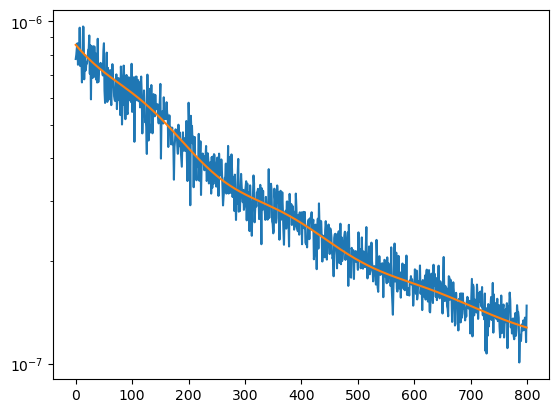

In [2]:
import numpy as np
import jax_cosmo as jc
import jax.numpy as jnp
import jax
import lbg_forecast.utils as utils
import matplotlib.pyplot as plt

import lbg_forecast.angular_power as ap


import jax.numpy as jnp
import jax_cosmo as jc

from jax_cosmo.redshift import delta_nz

from lbg_forecast import modified_probes
from jax_cosmo import probes
from jax_cosmo.angular_cl import angular_cl
from jax_cosmo.angular_cl import noise_cl
from jax_cosmo.angular_cl import gaussian_cl_covariance_and_mean
from jax_cosmo.angular_cl import gaussian_cl_covariance

from lbg_forecast.modified_bias import constant_linear_bias

from lbg_forecast.modified_redshift import u_dropout
from lbg_forecast.modified_redshift import g_dropout
from lbg_forecast.modified_redshift import r_dropout

from lbg_forecast.modified_redshift import u_dropout_noint
from lbg_forecast.modified_redshift import g_dropout_noint
from lbg_forecast.modified_redshift import r_dropout_noint

mean_vec_u = jnp.load("4pca_data/npca_means_u.npy")
mean_vec_g = jnp.load("4pca_data/npca_means_g.npy")
mean_vec_r = jnp.load("4pca_data/npca_means_r.npy")

cov_u = jnp.load("4pca_data/npca_cov_u.npy")
cov_g = jnp.load("4pca_data/npca_cov_g.npy")
cov_r = jnp.load("4pca_data/npca_cov_r.npy")


nz_params_mean = jnp.hstack(
    (mean_vec_u, mean_vec_g, mean_vec_r)
)

nden_u = 8000/utils.DEG2_TO_ARCMIN2
nden_g = 14000/utils.DEG2_TO_ARCMIN2
nden_r = 1100/utils.DEG2_TO_ARCMIN2
seed=100

NPCA=50
n = NPCA
f_sky = 0.35
cosmo=jc.Planck15()
ell = jnp.arange(200, 1000, 1)

surface_of_last_scattering = delta_nz(1100., gals_per_arcmin2 = 1e20) 

nz_u = u_dropout(nz_params_mean[:n], gals_per_arcmin2=nden_u)
nz_g = g_dropout(nz_params_mean[n : 2 * n], gals_per_arcmin2=nden_g)
nz_r = r_dropout(nz_params_mean[2 * n : 3 * n], gals_per_arcmin2=nden_r)

redshift_distributions = [nz_u, nz_g, nz_r]

bias = [
    constant_linear_bias(3),
    constant_linear_bias(4),
    constant_linear_bias(5),
]

cosmo_probes = [probes.NumberCounts(redshift_distributions, bias),modified_probes.WeakLensing([surface_of_last_scattering])]

cl_signal, cov = gaussian_cl_covariance_and_mean(cosmo, ell, cosmo_probes, f_sky=f_sky, sparse=False)
cl_noise = noise_cl(ell, cosmo_probes).flatten()

total_cl = cl_signal + cl_noise
key = jax.random.PRNGKey(seed)
key, subkey = jax.random.split(key)
total_cl_cosmic_var = jax.random.multivariate_normal(key=subkey, mean=total_cl, cov=cov)
noisy_cl = total_cl*jax.random.chisquare(key=subkey, df=(2*f_sky*jnp.repeat(ell, repeats=10)+1))/(2*jnp.repeat(ell, repeats=10)*f_sky+1)

n=0
plt.plot(noisy_cl[800*n:800*(n+1)])
plt.plot(total_cl[800*n:800*(n+1)])
plt.yscale('log')



In [2]:
cov.shape, total_cl.shape

((8000, 8000), (8000,))

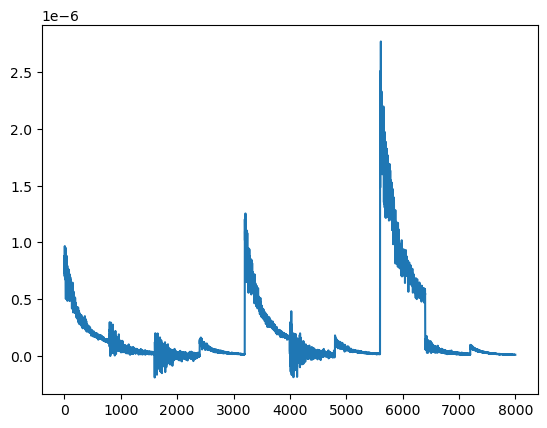

In [16]:
key = jax.random.PRNGKey(seed)
key, subkey = jax.random.split(key)
plt.plot(jax.random.multivariate_normal(key=subkey, mean=total_cl, cov=cov))
#plt.yscale('log')

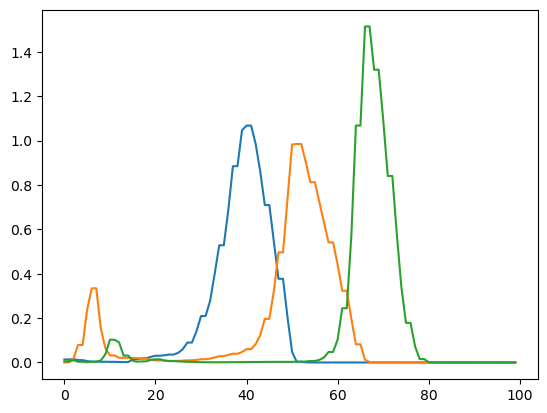

In [3]:
from lbg_forecast.modified_redshift import u_dropout_noint
from lbg_forecast.modified_redshift import g_dropout_noint
from lbg_forecast.modified_redshift import r_dropout_noint
import numpy as np

mean_vec_u_noint = jnp.load("4pca_data/npca_noint_means_u.npy")
mean_vec_g_noint = jnp.load("4pca_data/npca_noint_means_g.npy")
mean_vec_r_noint = jnp.load("4pca_data/npca_noint_means_r.npy")

mean_vec_u = jnp.load("4pca_data/npca_means_u.npy")
mean_vec_g = jnp.load("4pca_data/npca_means_g.npy")
mean_vec_r = jnp.load("4pca_data/npca_means_r.npy")

u_drop = u_dropout(mean_vec_u, red=0.1)

g_drop = g_dropout(mean_vec_u)

r_drop = r_dropout(mean_vec_r)


plt.plot(u_drop.pz_fn(np.linspace(0, 7, 100)))

plt.plot(g_drop.pz_fn(np.linspace(0, 7, 100)))

plt.plot(r_drop.pz_fn(np.linspace(0, 7, 100)))